# Genome Browser-style Visualization (Pseudo-coverage Track)\n\nFragment 파일 없이 **peak × cell count matrix** 기반으로 genome browser 스타일 시각화\n\n- 특정 유전자 주변 peak들의 평균 접근성을 그룹별(Cirrhosis vs Hepatitis)로 표시\n- Gene annotation track 포함\n- DA 결과(log2FC, significance) 오버레이\n\n**Target genes**: HNF4A, CYP3A4, CTCF, RXRG, NFIC

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

# ─── 경로 설정 ───
DATA_DIR = "/data1/project2/yeonu/cirrhosis/multiome/"
DA_DIR   = "/data1/project/yeonu/065_multi_atac/DA/results_output/"
LINK_DIR = "/data1/project/yeonu/065_multi_atac/Linkage/results_output/"
FIG_DIR  = "/data1/project/yeonu/065_multi_atac/fig/"

# ─── 타겟 유전자 (GRN Top Master Regulators + Key Targets) ───
TARGET_GENES = ["HNF4A", "CYP3A4", "CTCF", "RXRG", "NFIC"]

# ─── 시각화 범위 (유전자 좌우 확장) ───
FLANK_KB = 200  # 유전자 앞뒤 200kb

print("Setup complete.")

Setup complete.


## 1. 데이터 로드

In [3]:
# ─── 메타데이터 로드 ───
meta = pd.read_csv(DATA_DIR + "rna_cell_metadata.csv", index_col=0)
print(f"Total cells: {len(meta)}")
print(f"Groups: {meta['group'].value_counts().to_dict()}")
print(f"Status: {meta['status'].value_counts().to_dict()}")
print(f"Cell types: {meta['celltype_assign'].value_counts().to_dict()}")

Total cells: 28859
Groups: {'TC': 12501, 'NT': 8840, 'PL': 7518}
Status: {'Hepatitis': 26099, 'Cirrhosis': 2760}
Cell types: {'T_Cells': 8633, 'NK_Cells': 5194, 'Hepatocytes': 4774, 'Macrophages': 4280, 'Mesenchymal': 3609, 'Plasma_Cells': 952, 'DCs': 775, 'Endothelial_Cells': 403, 'B_Cells': 239}


In [4]:
# ─── ATAC sparse counts 로드 (TC Hepatocytes만) ───
# TC Hepatocytes 셀 목록
tc_hep_cells = meta[(meta['group'] == 'TC') & (meta['celltype_assign'] == 'Hepatocytes')].index.tolist()
print(f"TC Hepatocytes: {len(tc_hep_cells)} cells")

# Status 별 셀 분류
cirrhosis_cells = meta.loc[tc_hep_cells][meta.loc[tc_hep_cells, 'status'] == 'Cirrhosis'].index.tolist()
hepatitis_cells = meta.loc[tc_hep_cells][meta.loc[tc_hep_cells, 'status'] == 'Hepatitis'].index.tolist()
print(f"  Cirrhosis: {len(cirrhosis_cells)} cells")
print(f"  Hepatitis: {len(hepatitis_cells)} cells")

TC Hepatocytes: 2734 cells
  Cirrhosis: 175 cells
  Hepatitis: 2559 cells


In [5]:
# ─── ATAC sparse counts 로드 (TC Hepatocytes에 해당하는 행만) ───
print("Loading ATAC sparse counts (TC Hepatocytes only)... This may take a few minutes.")

tc_hep_set = set(tc_hep_cells)
chunks = []
for chunk in pd.read_csv(DATA_DIR + "atac_counts_sparse.csv", chunksize=5_000_000):
    filtered = chunk[chunk['cell_id'].isin(tc_hep_set)]
    if len(filtered) > 0:
        chunks.append(filtered)
    
atac_sparse = pd.concat(chunks, ignore_index=True)
print(f"Loaded {len(atac_sparse):,} non-zero entries for TC Hepatocytes")
print(f"Unique peaks: {atac_sparse['peak'].nunique():,}")
print(f"Unique cells: {atac_sparse['cell_id'].nunique():,}")

Loading ATAC sparse counts (TC Hepatocytes only)... This may take a few minutes.
Loaded 7,413,544 non-zero entries for TC Hepatocytes
Unique peaks: 76,820
Unique cells: 2,734


In [6]:
# ─── Peak 좌표 파싱 ───
def parse_peak(peak_str):
    """chr1-12345-67890 → (chr1, 12345, 67890)"""
    parts = peak_str.split("-")
    return parts[0], int(parts[1]), int(parts[2])

# 모든 peak 좌표 테이블 생성
all_peaks = atac_sparse['peak'].unique()
peak_info = pd.DataFrame([parse_peak(p) for p in all_peaks], 
                          columns=['chrom', 'start', 'end'], index=all_peaks)
peak_info['center'] = (peak_info['start'] + peak_info['end']) // 2
print(f"Peak coordinate table: {len(peak_info)} peaks")

Peak coordinate table: 76820 peaks


In [7]:
# ─── DA 결과 로드 ───
da_results = pd.read_csv(DA_DIR + "DA_results_Hepatocytes.csv")
da_results = da_results.set_index('peak')
print(f"DA results: {len(da_results)} peaks")
print(f"Columns: {list(da_results.columns)}")
print(f"Significant (padj<0.05): {(da_results['padj'] < 0.05).sum()}")

# ─── Peak-Gene Links 로드 ───
links = pd.read_csv(LINK_DIR + "Hepatocyte_Peak_Gene_Links.csv", index_col=0)
print(f"\nPeak-Gene Links: {len(links)} links")
print(f"Unique genes linked: {links['gene'].nunique()}")

DA results: 17938 peaks
Columns: ['log2FC', 'pct.1', 'pct.2', 'pvalue', 'padj']
Significant (padj<0.05): 689

Peak-Gene Links: 13297 links
Unique genes linked: 6040


In [8]:
# ─── 유전자 좌표 정의 (hg38, EnsDb.Hsapiens.v86 기준) ───
# UCSC Genome Browser / Ensembl 에서 확인한 좌표
GENE_COORDS = {
    "HNF4A":  {"chrom": "chr20", "start": 44355803, "end": 44432845, "strand": "+"},
    "CYP3A4": {"chrom": "chr7",  "start": 99756960, "end": 99784247, "strand": "-"},
    "CTCF":   {"chrom": "chr16", "start": 67596310, "end": 67673088, "strand": "+"},
    "RXRG":   {"chrom": "chr1",  "start": 165370277, "end": 165417049, "strand": "+"},
    "NFIC":   {"chrom": "chr19", "start": 3357152, "end": 3436880,  "strand": "+"},
}

for gene, coord in GENE_COORDS.items():
    size_kb = (coord['end'] - coord['start']) / 1000
    print(f"{gene}: {coord['chrom']}:{coord['start']:,}-{coord['end']:,} ({size_kb:.1f} kb, {coord['strand']})")

HNF4A: chr20:44,355,803-44,432,845 (77.0 kb, +)
CYP3A4: chr7:99,756,960-99,784,247 (27.3 kb, -)
CTCF: chr16:67,596,310-67,673,088 (76.8 kb, +)
RXRG: chr1:165,370,277-165,417,049 (46.8 kb, +)
NFIC: chr19:3,357,152-3,436,880 (79.7 kb, +)


## 2. 그룹별 평균 접근성 계산

In [9]:
# ─── 그룹별 평균 접근성 계산 ───
cirrhosis_set = set(cirrhosis_cells)
hepatitis_set = set(hepatitis_cells)

# Cirrhosis / Hepatitis 분리
atac_cirr = atac_sparse[atac_sparse['cell_id'].isin(cirrhosis_set)]
atac_hepa = atac_sparse[atac_sparse['cell_id'].isin(hepatitis_set)]

# Peak 별 평균 접근성 (sum / n_cells)
n_cirr = len(cirrhosis_cells)
n_hepa = len(hepatitis_cells)

mean_cirr = atac_cirr.groupby('peak')['value'].sum() / n_cirr
mean_hepa = atac_hepa.groupby('peak')['value'].sum() / n_hepa

# CPM-like normalization (× 10000 for visibility)
mean_cirr = mean_cirr * 10000
mean_hepa = mean_hepa * 10000

print(f"Cirrhosis: {len(mean_cirr)} peaks with signal (normalized by {n_cirr} cells)")
print(f"Hepatitis: {len(mean_hepa)} peaks with signal (normalized by {n_hepa} cells)")

Cirrhosis: 68841 peaks with signal (normalized by 175 cells)
Hepatitis: 76799 peaks with signal (normalized by 2559 cells)


## 3. Genome Browser-style Visualization 함수

In [10]:
def plot_browser_track(gene_name, gene_coords, mean_cirr, mean_hepa, 
                        peak_info, da_results, links, flank_kb=200):
    """
    Genome browser-style pseudo-coverage track.
    
    Layout (4 panels):
      [1] Cirrhosis coverage track
      [2] Hepatitis coverage track  
      [3] DA log2FC track (significance colored)
      [4] Gene annotation + Peak-Gene links
    """
    chrom = gene_coords['chrom']
    gene_start = gene_coords['start']
    gene_end = gene_coords['end']
    strand = gene_coords['strand']
    
    # Region 범위
    region_start = gene_start - flank_kb * 1000
    region_end = gene_end + flank_kb * 1000
    
    # 이 region에 속하는 peaks 필터
    region_peaks = peak_info[
        (peak_info['chrom'] == chrom) &
        (peak_info['end'] >= region_start) &
        (peak_info['start'] <= region_end)
    ].copy()
    
    if len(region_peaks) == 0:
        print(f"  {gene_name}: No peaks found in {chrom}:{region_start:,}-{region_end:,}")
        return
    
    # 접근성 값 매핑
    region_peaks['cirrhosis'] = region_peaks.index.map(mean_cirr).fillna(0)
    region_peaks['hepatitis'] = region_peaks.index.map(mean_hepa).fillna(0)
    
    # DA 결과 매핑
    region_peaks['log2FC'] = region_peaks.index.map(da_results['log2FC']).fillna(0)
    region_peaks['padj'] = region_peaks.index.map(da_results['padj']).fillna(1)
    region_peaks['is_sig'] = region_peaks['padj'] < 0.05
    
    # Peak-Gene links for this gene
    gene_links = links[links['gene'] == gene_name].copy() if gene_name in links['gene'].values else pd.DataFrame()
    
    region_peaks = region_peaks.sort_values('start')
    
    # ─── Figure 설정 ───
    fig, axes = plt.subplots(4, 1, figsize=(14, 8), 
                              gridspec_kw={'height_ratios': [2, 2, 1.5, 1.5]},
                              sharex=True)
    
    COLOR_CIRR = '#C44E52'
    COLOR_HEPA = '#8172B3'
    
    # ─── [1] Cirrhosis Track ───
    ax = axes[0]
    for _, pk in region_peaks.iterrows():
        ax.fill_between([pk['start'], pk['end']], 0, pk['cirrhosis'],
                        color=COLOR_CIRR, alpha=0.8, linewidth=0)
    ax.set_ylabel('Accessibility', fontsize=9)
    ax.set_title(f'{gene_name} — {chrom}:{region_start:,}-{region_end:,}', 
                 fontsize=12, fontweight='bold', loc='left')
    ax.text(0.98, 0.85, f'Cirrhosis (n={len(cirrhosis_cells)})', 
            transform=ax.transAxes, ha='right', fontsize=10, color=COLOR_CIRR, fontweight='bold')
    ax.set_xlim(region_start, region_end)
    ymax = max(region_peaks['cirrhosis'].max(), region_peaks['hepatitis'].max()) * 1.1
    if ymax == 0:
        ymax = 1
    ax.set_ylim(0, ymax)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # ─── [2] Hepatitis Track ───
    ax = axes[1]
    for _, pk in region_peaks.iterrows():
        ax.fill_between([pk['start'], pk['end']], 0, pk['hepatitis'],
                        color=COLOR_HEPA, alpha=0.8, linewidth=0)
    ax.set_ylabel('Accessibility', fontsize=9)
    ax.text(0.98, 0.85, f'Hepatitis (n={len(hepatitis_cells)})', 
            transform=ax.transAxes, ha='right', fontsize=10, color=COLOR_HEPA, fontweight='bold')
    ax.set_ylim(0, ymax)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # ─── [3] DA log2FC Track ───
    ax = axes[2]
    for _, pk in region_peaks.iterrows():
        color = '#E74C3C' if pk['log2FC'] > 0 and pk['is_sig'] else \
                '#3498DB' if pk['log2FC'] < 0 and pk['is_sig'] else '#CCCCCC'
        alpha = 0.9 if pk['is_sig'] else 0.4
        ax.bar(pk['center'], pk['log2FC'], 
               width=pk['end'] - pk['start'], color=color, alpha=alpha, linewidth=0)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='-')
    ax.set_ylabel('log2FC\n(Cirr/Hep)', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # DA legend
    sig_up = mpatches.Patch(color='#E74C3C', alpha=0.9, label='Up in Cirrhosis (padj<0.05)')
    sig_down = mpatches.Patch(color='#3498DB', alpha=0.9, label='Up in Hepatitis (padj<0.05)')
    ns = mpatches.Patch(color='#CCCCCC', alpha=0.4, label='Not significant')
    ax.legend(handles=[sig_up, sig_down, ns], fontsize=7, loc='upper right', framealpha=0.8)
    
    # ─── [4] Gene Annotation + Links ───
    ax = axes[3]
    ax.set_ylim(-1, 2)
    
    # Gene body
    gene_color = '#2C3E50'
    ax.fill_between([gene_start, gene_end], 0.3, 0.7, color=gene_color, alpha=0.8)
    
    # Arrow for strand direction
    arrow_y = 0.5
    if strand == '+':
        ax.annotate('', xy=(gene_end, arrow_y), xytext=(gene_start, arrow_y),
                     arrowprops=dict(arrowstyle='->', color=gene_color, lw=2))
    else:
        ax.annotate('', xy=(gene_start, arrow_y), xytext=(gene_end, arrow_y),
                     arrowprops=dict(arrowstyle='->', color=gene_color, lw=2))
    
    # Gene label
    gene_mid = (gene_start + gene_end) / 2
    ax.text(gene_mid, 1.0, gene_name, ha='center', va='bottom', fontsize=11,
            fontweight='bold', fontstyle='italic', color=gene_color)
    
    # Peak-Gene links (arcs)
    if len(gene_links) > 0:
        for _, lk in gene_links.iterrows():
            peak_name = lk['peak']
            if peak_name in peak_info.index:
                pk_center = peak_info.loc[peak_name, 'center']
                if region_start <= pk_center <= region_end:
                    score = abs(lk.get('score', 0.05))
                    arc_color = '#E67E22' if score > 0.1 else '#BDC3C7'
                    ax.annotate('', xy=(pk_center, 0.3), xytext=(gene_mid, 0.3),
                               arrowprops=dict(arrowstyle='-', color=arc_color, 
                                             lw=0.8, connectionstyle='arc3,rad=-0.3',
                                             alpha=0.6))
    
    ax.set_ylabel('Gene', fontsize=9)
    ax.set_xlabel(f'Genomic position ({chrom})', fontsize=10)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # x-axis formatting (Mb)
    from matplotlib.ticker import FuncFormatter
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1e6:.2f} Mb'))
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    n_peaks = len(region_peaks)
    n_sig = region_peaks['is_sig'].sum()
    n_links = len(gene_links)
    print(f"  {gene_name}: {n_peaks} peaks in region, {n_sig} significant DARs, {n_links} peak-gene links")

print("plot_browser_track() defined.")

plot_browser_track() defined.


## 4. 5개 유전자 시각화 실행


  HNF4A


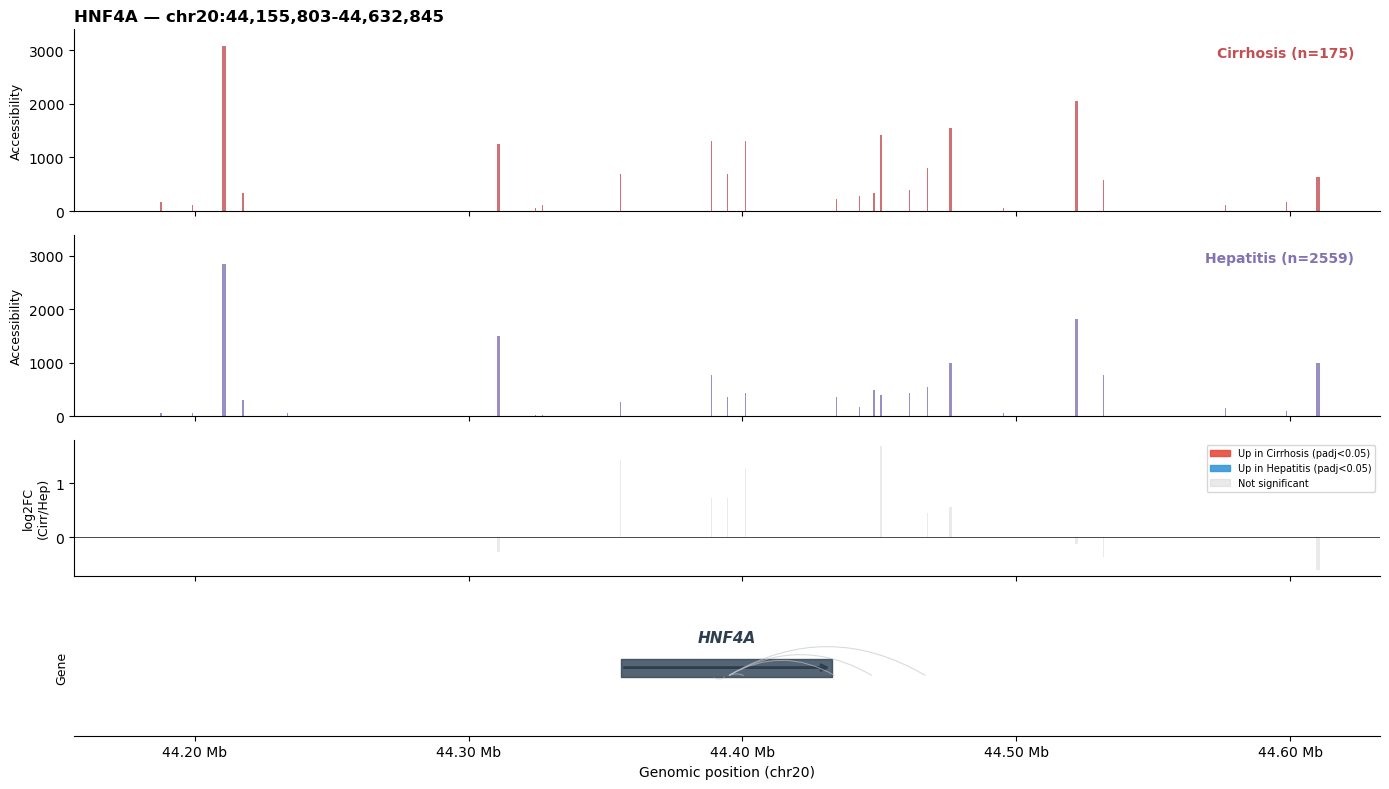

  HNF4A: 28 peaks in region, 0 significant DARs, 7 peak-gene links

  CYP3A4


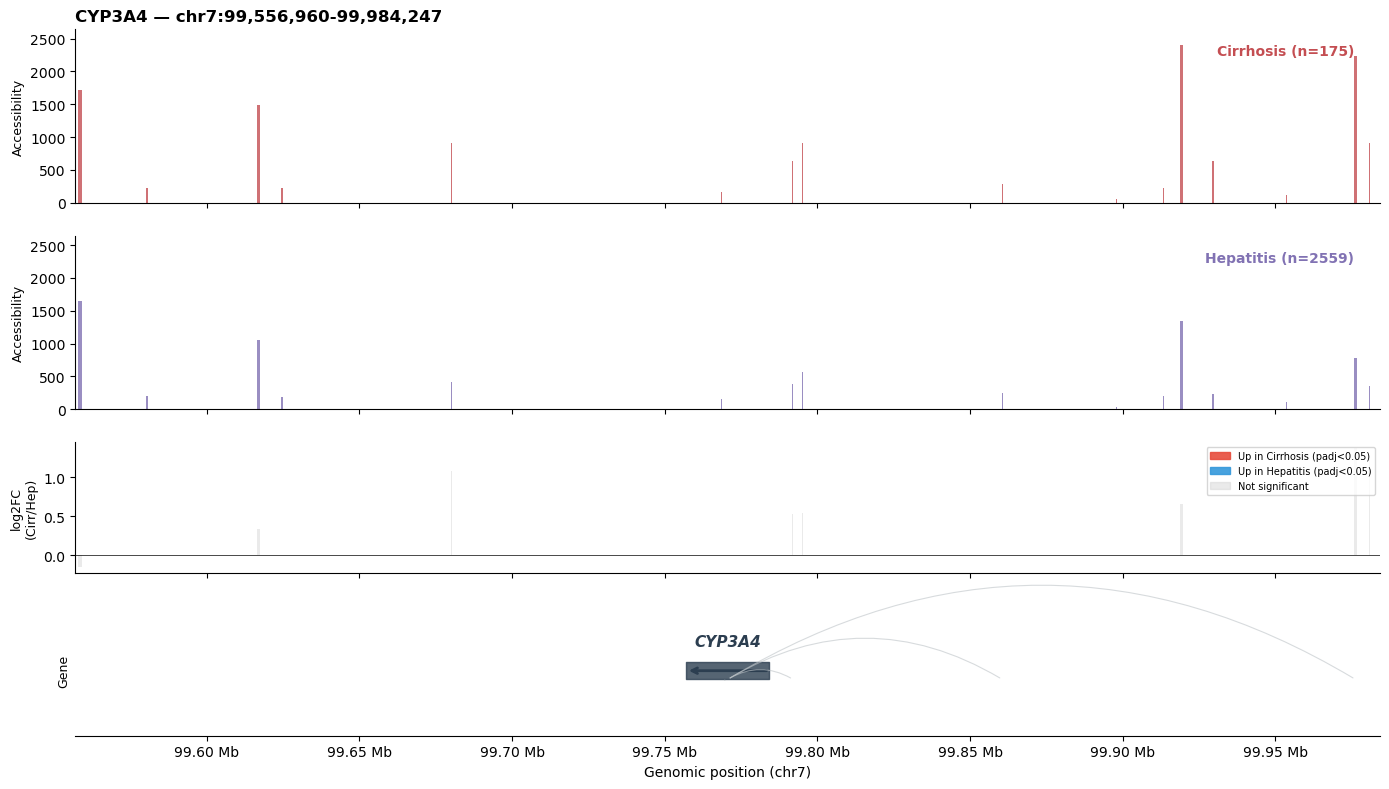

  CYP3A4: 18 peaks in region, 0 significant DARs, 8 peak-gene links

  CTCF


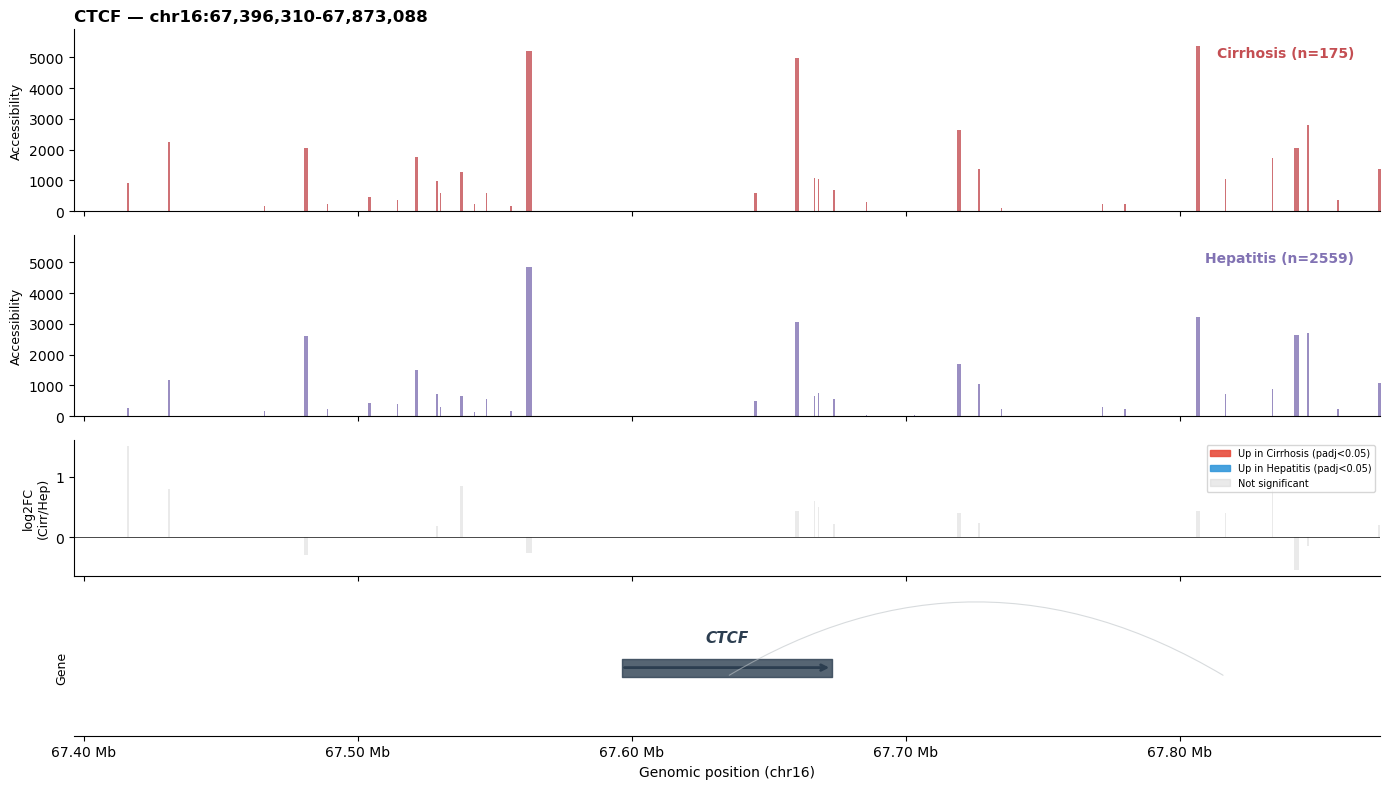

  CTCF: 37 peaks in region, 0 significant DARs, 2 peak-gene links

  RXRG


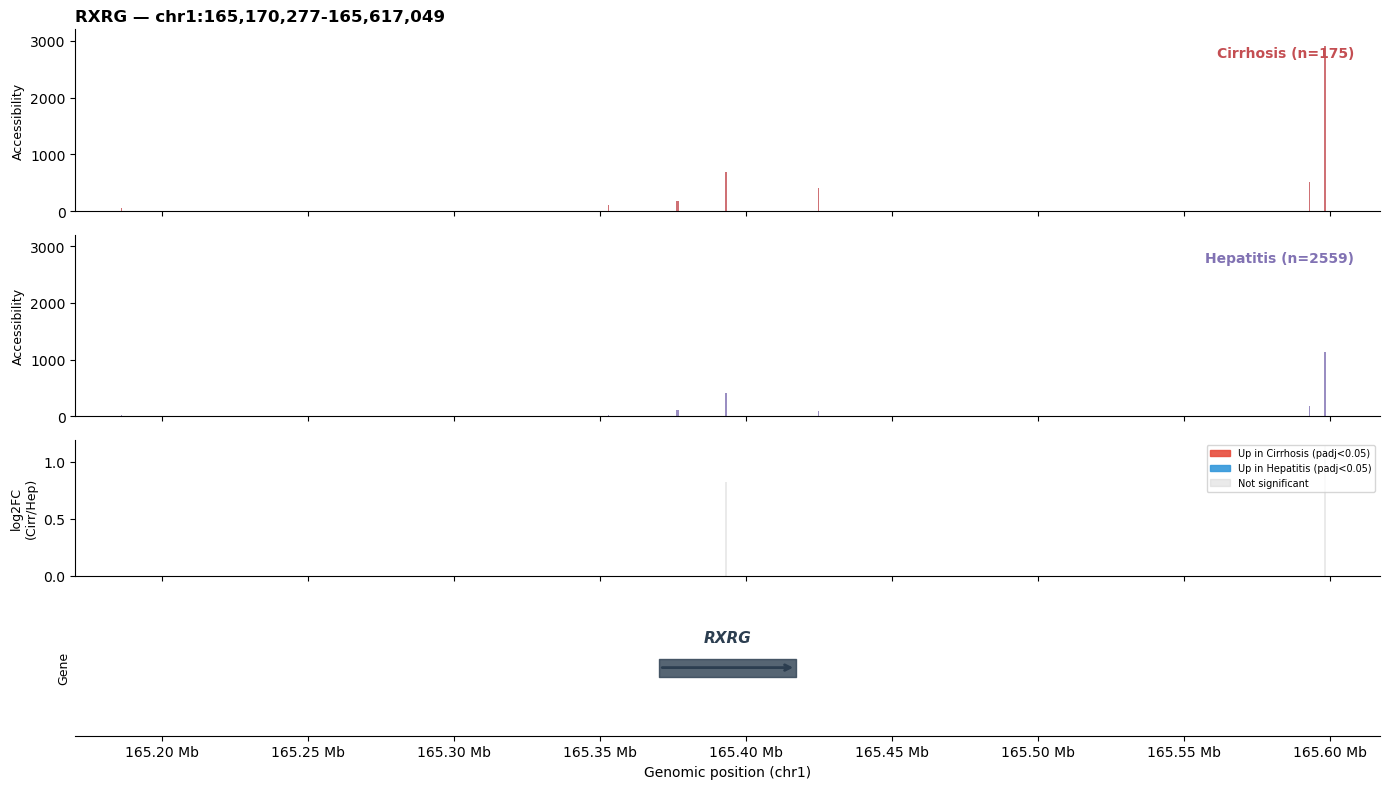

  RXRG: 7 peaks in region, 0 significant DARs, 0 peak-gene links

  NFIC


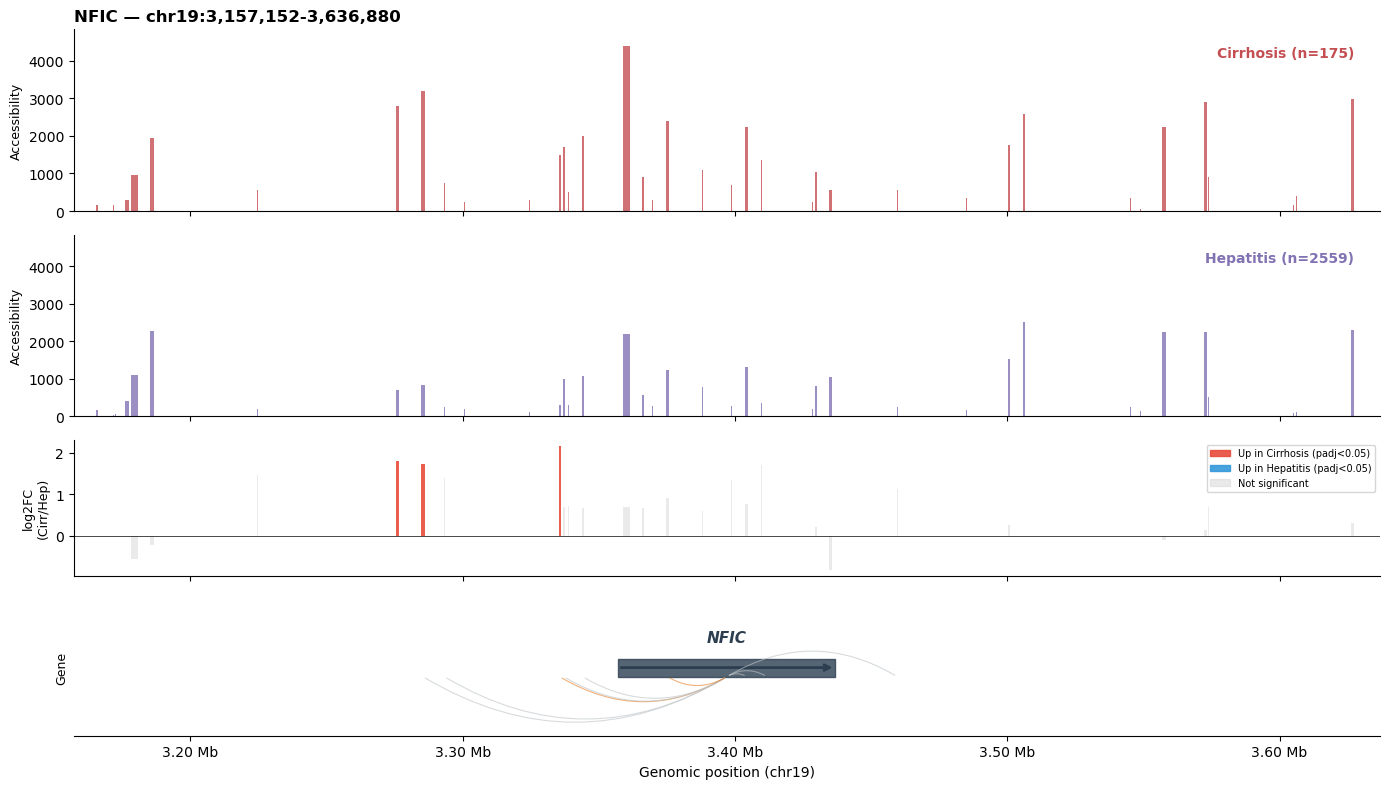

  NFIC: 43 peaks in region, 3 significant DARs, 10 peak-gene links


In [11]:
# ─── 5개 유전자 Browser Track 생성 ───
for gene in TARGET_GENES:
    print(f"\n{'='*60}")
    print(f"  {gene}")
    print(f"{'='*60}")
    plot_browser_track(
        gene_name=gene,
        gene_coords=GENE_COORDS[gene],
        mean_cirr=mean_cirr,
        mean_hepa=mean_hepa,
        peak_info=peak_info,
        da_results=da_results,
        links=links,
        flank_kb=FLANK_KB
    )

## 5. Combined Figure (5개 유전자 한 장)

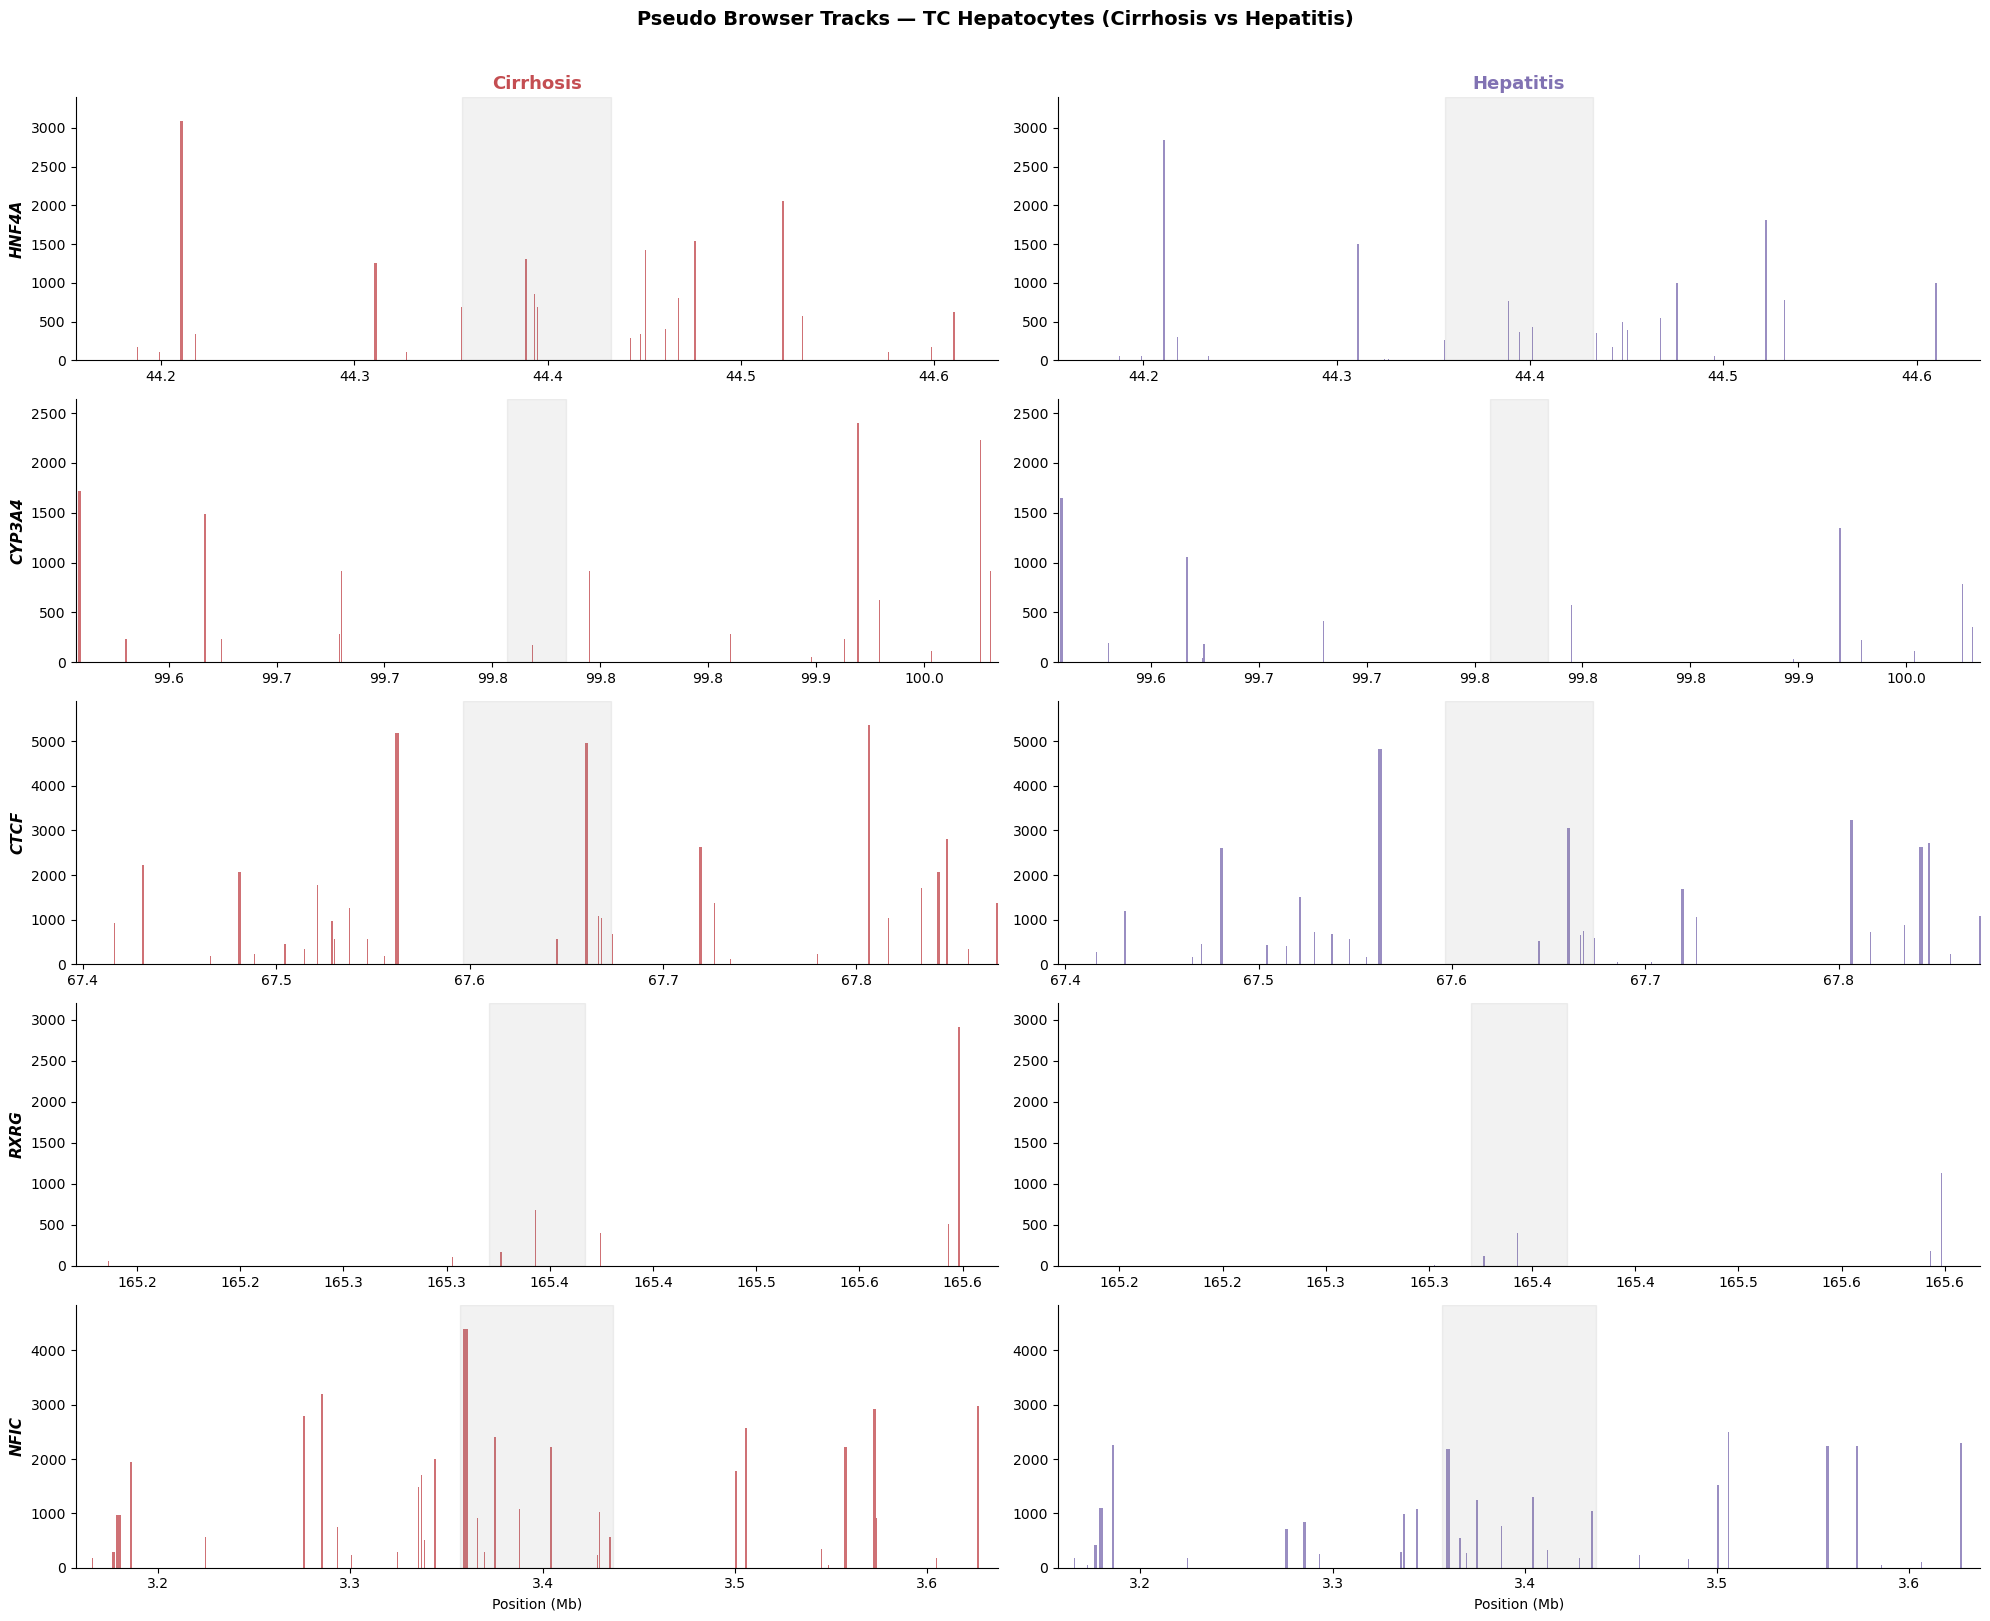

In [12]:
# ─── Combined: 5개 유전자 × 2 tracks (Cirrhosis vs Hepatitis) ───
fig, axes = plt.subplots(5, 2, figsize=(20, 16), sharex=False)

COLOR_CIRR = '#C44E52'
COLOR_HEPA = '#8172B3'

for row_idx, gene in enumerate(TARGET_GENES):
    gc = GENE_COORDS[gene]
    chrom = gc['chrom']
    region_start = gc['start'] - FLANK_KB * 1000
    region_end = gc['end'] + FLANK_KB * 1000
    
    rp = peak_info[
        (peak_info['chrom'] == chrom) &
        (peak_info['end'] >= region_start) &
        (peak_info['start'] <= region_end)
    ].copy().sort_values('start')
    
    rp['cirrhosis'] = rp.index.map(mean_cirr).fillna(0)
    rp['hepatitis'] = rp.index.map(mean_hepa).fillna(0)
    
    ymax = max(rp['cirrhosis'].max(), rp['hepatitis'].max()) * 1.1
    if ymax == 0:
        ymax = 1
    
    # Cirrhosis
    ax = axes[row_idx, 0]
    for _, pk in rp.iterrows():
        ax.fill_between([pk['start'], pk['end']], 0, pk['cirrhosis'],
                        color=COLOR_CIRR, alpha=0.8, linewidth=0)
    ax.axvspan(gc['start'], gc['end'], alpha=0.1, color='grey')
    ax.set_xlim(region_start, region_end)
    ax.set_ylim(0, ymax)
    ax.set_ylabel(f'{gene}', fontsize=11, fontweight='bold', fontstyle='italic')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if row_idx == 0:
        ax.set_title('Cirrhosis', fontsize=13, fontweight='bold', color=COLOR_CIRR)
    
    from matplotlib.ticker import FuncFormatter
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1e6:.1f}'))
    if row_idx == 4:
        ax.set_xlabel('Position (Mb)', fontsize=10)
    
    # Hepatitis
    ax = axes[row_idx, 1]
    for _, pk in rp.iterrows():
        ax.fill_between([pk['start'], pk['end']], 0, pk['hepatitis'],
                        color=COLOR_HEPA, alpha=0.8, linewidth=0)
    ax.axvspan(gc['start'], gc['end'], alpha=0.1, color='grey')
    ax.set_xlim(region_start, region_end)
    ax.set_ylim(0, ymax)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if row_idx == 0:
        ax.set_title('Hepatitis', fontsize=13, fontweight='bold', color=COLOR_HEPA)
    
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1e6:.1f}'))
    if row_idx == 4:
        ax.set_xlabel('Position (Mb)', fontsize=10)

plt.suptitle('Pseudo Browser Tracks — TC Hepatocytes (Cirrhosis vs Hepatitis)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()